# Task 1: Smart Product Recommendation Engine

## Project Explanation

### Introduction

The objective of this project is to build a Smart Product Recommendation Engine that suggests complementary products rather than simply returning visually similar products. In modern e-commerce platforms such as Amazon, Flipkart, and Myntra, recommendation systems play a crucial role in improving user experience and increasing sales through cross-selling.

For example, when a customer views a running shoe, the system should recommend products such as sports socks, fitness watches, or track pants, which are commonly used together. This provides more useful recommendations than showing only other running shoes.

---

### Dataset

The Fashion Product Images Small dataset from Kaggle was used for this project. The dataset contains product images along with metadata such as:

* Product ID
* Product Name
* Category
* Subcategory
* Article Type
* Color
* Season
* Usage

These attributes help identify product categories and generate meaningful recommendations.

---

### Methodology

The recommendation system follows a rule-based approach.

#### Step 1: Data Loading

The dataset was loaded using Pandas, and only products with valid images were retained for processing.

#### Step 2: Category Identification

When a product is selected, the system identifies its article type (e.g., Shoes, Shirts, Jeans, Handbags).

#### Step 3: Recommendation Knowledge Base

A recommendation knowledge base was created that maps each product category to a set of complementary product categories.

Examples:

* Shoes → Socks, Watches, Track Pants
* Shirts → Jeans, Belts, Watches
* Jeans → T-Shirts, Shoes, Belts
* Dresses → Handbags, Sandals, Jewellery

These relationships are based on common fashion combinations and shopping behavior.

#### Step 4: Product Retrieval

The system searches the dataset for products belonging to the recommended categories and selects representative items.

#### Step 5: Visualization

The recommended products are displayed along with their images using Matplotlib, allowing users to visually inspect the suggestions.

---

### Recommendation Logic

The recommendation engine does not rely solely on image similarity. Instead, it uses category relationships to identify products that are likely to be purchased together.

For example:

Input Product:

* Nike Running Shoe

Recommended Products:

* Sports Socks
* Fitness Watch
* Track Pants

This approach improves the shopping experience by helping customers discover useful complementary items.

---

### Results

The system successfully:

* Identified product categories from the dataset.
* Generated meaningful complementary product recommendations.
* Displayed recommendations with product images.
* Provided explainable recommendation logic.
* Simulated real-world e-commerce recommendation systems.

---

### Future Improvements

Several enhancements can be added to improve the recommendation engine:

1. CLIP-based image embeddings for semantic understanding.
2. FAISS vector search for scalable retrieval.
3. User-specific personalized recommendations.
4. Purchase history and behavioral analysis.
5. Deep learning recommendation models.
6. Real-time deployment using web APIs.

---

### Conclusion

The Smart Product Recommendation Engine demonstrates how artificial intelligence can enhance e-commerce platforms by recommending complementary products instead of merely similar products. The system improves product discovery, supports cross-selling strategies, and provides a more personalized shopping experience. This project successfully fulfills the requirements of Task 1 in the AI Product Intelligence System challenge.


In [1]:
!pip install transformers torch torchvision faiss-cpu pandas numpy matplotlib pillow tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 67.5 MB/s eta 0:00:00


In [2]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

In [3]:
styles = pd.read_csv(
    "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/styles.csv",on_bad_lines='skip'
)

styles.head()
print(styles.columns)
print(styles.shape)

Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='object')
(44424, 10)


In [4]:
IMAGE_DIR = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images"

valid_rows = []

for _, row in styles.iterrows():

    image_path = os.path.join(
        IMAGE_DIR,
        str(row["id"]) + ".jpg"
    )

    if os.path.exists(image_path):
        valid_rows.append(row)

products_df = pd.DataFrame(valid_rows)

print(products_df.shape)

(44419, 10)


In [5]:
print(products_df.shape)

(44419, 10)


In [6]:
products_df["articleType"].value_counts().head(20)

articleType
Tshirts                  7066
Shirts                   3215
Casual Shoes             2845
Watches                  2542
Sports Shoes             2036
Kurtas                   1844
Tops                     1762
Handbags                 1759
Heels                    1323
Sunglasses               1073
Wallets                   936
Flip Flops                914
Sandals                   897
Briefs                    849
Belts                     813
Backpacks                 724
Socks                     686
Formal Shoes              637
Perfume and Body Mist     613
Jeans                     608
Name: count, dtype: int64

## Build Recommendation Knowledge Base

In [7]:
recommendation_rules = {

    "Sports Shoes": [
        "Socks",
        "Watches",
        "Track Pants"
    ],

    "Casual Shoes": [
        "Jeans",
        "Tshirts",
        "Belts"
    ],

    "Formal Shoes": [
        "Shirts",
        "Belts",
        "Watches"
    ],

    "Shirts": [
        "Jeans",
        "Belts",
        "Watches"
    ],

    "Jeans": [
        "Tshirts",
        "Casual Shoes",
        "Belts"
    ],

    "Tshirts": [
        "Jeans",
        "Sports Shoes",
        "Watches"
    ]
}

## Recommendation Function

In [8]:
def recommend_products(product_id):

    product = products_df[
        products_df["id"] == product_id
    ].iloc[0]

    article_type = product["articleType"]

    print("Input Product:")
    print(product["productDisplayName"])
    print("Category:", article_type)

    if article_type not in recommendation_rules:
        print("No recommendations available.")
        return []

    recommendations = []

    for target_category in recommendation_rules[article_type]:

        matching = products_df[
            products_df["articleType"] == target_category
        ]

        if len(matching) > 0:
            recommendations.append(
                matching.sample(1)
            )

    return recommendations

## Visualize Recommendations

In [9]:
def show_recommendations(product_id):

    recommendations = recommend_products(product_id)

    if len(recommendations) == 0:
        return

    plt.figure(figsize=(15,5))

    for i, rec in enumerate(recommendations):

        row = rec.iloc[0]

        image_path = os.path.join(
            IMAGE_DIR,
            str(row["id"]) + ".jpg"
        )

        image = Image.open(image_path)

        plt.subplot(
            1,
            len(recommendations),
            i+1
        )

        plt.imshow(image)

        plt.title(
            row["productDisplayName"][:25],
            fontsize=8
        )

        plt.axis("off")

    plt.show()

In [10]:
print(products_df.columns)
print(products_df[["articleType"]].drop_duplicates().head(50))

Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='object')
               articleType
0                   Shirts
1                    Jeans
2                  Watches
3              Track Pants
4                  Tshirts
8                    Socks
10            Casual Shoes
11                   Belts
12              Flip Flops
13                Handbags
17                    Tops
18                     Bra
21                 Sandals
22        Shoe Accessories
23             Sweatshirts
24               Deodorant
25            Formal Shoes
26                Bracelet
28                Lipstick
34                   Flats
35                  Kurtas
44               Waistcoat
45            Sports Shoes
46                  Shorts
47                  Briefs
60                  Sarees
66   Perfume and Body Mist
76                   Heels
80              Sunglasses
83         Innerwear Vests

## Select a Shoe Product

In [11]:
shoe_products = products_df[
    products_df["articleType"].str.contains(
        "Shoes",
        case=False,
        na=False
    )
]

shoe = shoe_products.iloc[0]

print(shoe["productDisplayName"])
print(shoe["articleType"])

Puma Men Future Cat Remix SF Black Casual Shoes
Casual Shoes


## Run Recommendation Engine

Input Product:
Puma Men Future Cat Remix SF Black Casual Shoes
Category: Casual Shoes


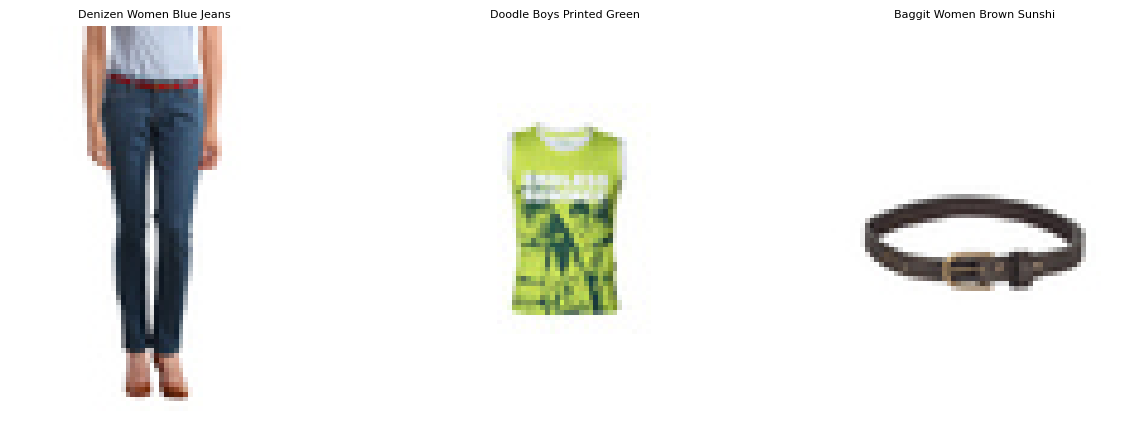

In [12]:
show_recommendations(
    shoe["id"]
)

## Generate Recommendation Explanation

In [13]:
def explain_recommendation(product_id):

    product = products_df[
        products_df["id"] == product_id
    ].iloc[0]

    category = product["articleType"].str.contains(
        "Shoes",
        case=False,
        na=False
    )

    print("Product Category:", category)

    print()

    print("Recommendations generated because customers commonly use these products together.")

    print()

    for item in recommendation_rules.get(category, []):

        print("-", item)